In [131]:
print("HoangHa")

HoangHa


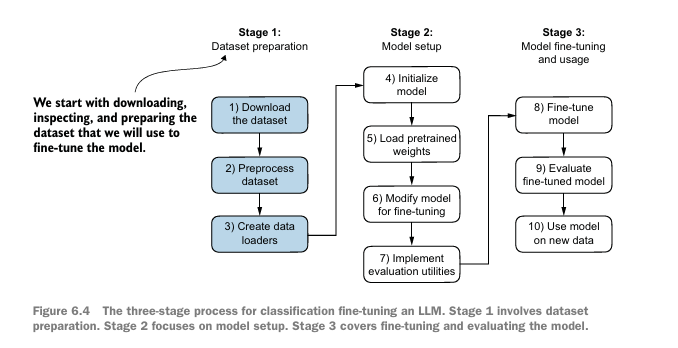

In [132]:
import urllib.request
import zipfile
import os
from pathlib import Path
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

In [133]:
def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path): 
    if data_file_path.exists(): 
        print(f"{data_file_path} already exists. Skipping download "
              "and extraction."
        )
        return
    with urllib.request.urlopen(url) as response:   
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())
    with zipfile.ZipFile(zip_path, "r") as zip_ref:   
        zip_ref.extractall(extracted_path)
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)              
    print(f"File downloaded and saved as {data_file_path}")


download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [134]:
import pandas as pd
df = pd.read_csv(
    data_file_path,  sep="\t", header=None, names=["Label", "Text"]
)
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [135]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [136]:
def create_balanced_dataset(df): 
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df[df["Label"]== "ham"].sample(
        num_spam,random_state=123
    )
    balanced_df = pd.concat([ham_subset, df[df["Label"]=="spam"]])
    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [137]:
balanced_df["Label"] = balanced_df["Label"].map({'ham':0, "spam":1})

### Split dataste

In [138]:
def random_split(df,train_frac,validation_frac): 
    df=df.sample(frac=1, random_state=123).reset_index(drop=True)
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df)*validation_frac)
    train_df = df[:train_end]
    validation_df = df[train_end : validation_end]
    test_df = df[validation_end :]
    return train_df,validation_df,test_df 

train_df , validation_df , test_df = random_split(balanced_df,0.7,0.1)

In [139]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

## Creating dataa loader

In [140]:
import torch 
from torch.utils.data import Dataset

class SpamDataset(Dataset): 
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256): 
        self.data = pd.read_csv(csv_file)
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]
        if max_length is None: 
            self.max_length = self._longest_encoded_length()
        else: 
            self.max_length = max_length
            self.encoded_texts = [
                encoded_text[:self.max_length] for encoded_text in self.encoded_texts
            ]
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index): 
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype = torch.long), 
            torch.tensor(label, dtype = torch.long)
        )
    def __len__(self): 
        return len(self.data)
    def _longest_encoded_length(self): 
        max_length=0
        for encoded_text in self.encoded_texts: 
            encoded_length = len(encoded_text)
            if encoded_length > max_length: 
                max_length = encoded_length
        return max_length

In [141]:
import tiktoken 
tokenizer = tiktoken.get_encoding("gpt2")

train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

In [142]:
print(train_dataset.max_length)

120


In [143]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

In [144]:
from torch.utils.data import DataLoader

num_workers =0
batch_size =8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size = batch_size, 
    num_workers = num_workers, 
    drop_last = True, 
    shuffle=True
)


val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)



In [145]:
for input_batch , target_batch in train_loader: 
    pass 
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [146]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [147]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

model_name = "gpt2"

tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

model.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [148]:
text = "Hoang ha is"

inputs = tokenizer(text, return_tensors="pt")

outputs = model.generate(
    **inputs,
    max_new_tokens=30
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Hoang ha is a very good player. He's a very good player. He's a very good player. He's a very good player. He's a very


In [149]:
text =  "Every effort moves you"

inputs = tokenizer(text, return_tensors="pt")

outputs = model.generate(
    **inputs,
    max_new_tokens=15
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Every effort moves you forward.

The first step is to understand the importance of your work


In [150]:
text =   (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

inputs = tokenizer(text, return_tensors="pt")

outputs = model.generate(
    **inputs,
    max_new_tokens=23
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


In [151]:
print(model)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


In [152]:
for param in model.parameters(): 
    param.requires_grad= False

In [153]:
BASE_CONFIG = {
    "vocab_size": 50257,         
    "context_length": 1024,      
    "drop_rate": 0.0,            
    "qkv_bias": True, 
    "emb_dim":768
}

In [154]:
torch.manual_seed(123)
num_classes = 2
model.lm_head=torch.nn.Linear(
    in_features = BASE_CONFIG["emb_dim"], 
    out_features=num_classes
)

In [155]:
# Block cuối
for param in model.transformer.h[-1].parameters():
    param.requires_grad = True

# Final LayerNorm
for param in model.transformer.ln_f.parameters():
    param.requires_grad = True


In [156]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [157]:
with torch.no_grad(): 
    outputs = model(inputs)


print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.logits.shape)

Outputs:
 CausalLMOutputWithCrossAttentions(loss=None, logits=tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]]), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer]), hidden_states=None, attentions=None, cross_attentions=None)
Outputs dimensions: torch.Size([1, 4, 2])


In [158]:
print("Last output token:", outputs.logits[:, -1, :])


Last output token: tensor([[-3.5983,  3.9902]])


## Calculating the classification loss and accuracy

In [159]:
probas = torch.softmax(outputs.logits[:,-1,:], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())


Class label: 1


In [160]:
logits = outputs.logits[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


In [161]:
def calc_accuracy_loader(data_loader , model, device, num_batches = None):
    model.eval()
    correct_predictions, num_examples =0,0
    if num_batches is None: 
        num_batches = len(data_loader)
    else: 
        num_batches = min(num_batches, len(data_loader))
    for i,(input_batch,target_batch) in enumerate(data_loader): 
        if i<num_batches : 
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            with torch.no_grad(): 
                logits = model(input_batch).logits[:,-1,:]
            predicted_labels = torch.argmax(logits, dim=-1)
            num_examples += predicted_labels.shape[0]
            correct_predictions += (
                (predicted_labels == target_batch).sum().item() 
            )
        else: 
            break
    return correct_predictions / num_examples

In [162]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10
)
val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10
)
test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10
)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


## Compute Loss

In [163]:
def calc_loss_batch(input_batch, target_batch, model, device): 
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch).logits[:,-1,:]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [164]:
def calc_loss_loader(data_loader , model , device , num_batches = None): 
    total_loss = 0
    if len(data_loader) == 0: 
        return float("nan")
    elif num_batches is None: 
        num_batches = len(data_loader)
    else: 
        num_batches = min(num_batches , len(data_loader))
    for i , (input_batch,target_batch) in enumerate(data_loader): 
        if i<num_batches: 
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else: 
            break
    return total_loss / num_batches

In [165]:
with torch.no_grad(): 
    train_loss = calc_loss_loader(
        train_loader , model, device, num_batches = 5
    )
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


In [166]:
def train_classifier_simple(
    model, train_loader, val_loader , optimizer, device, num_epochs, eval_freq, eval_iter
): 
    train_losses , val_losses, train_accs, val_accs = [], [], [] ,[]
    examples_seen, global_step = 0,-1
    for epoch in range(num_epochs): 
        model.train()
        for input_batch , target_batch in train_loader: 
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0] 
            global_step+=1
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )
        train_accuracy = calc_accuracy_loader(
                train_loader, model, device, num_batches=eval_iter
            )
        val_accuracy = calc_accuracy_loader(
                val_loader, model, device, num_batches=eval_iter
            )
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)
    return train_losses, val_losses, train_accs, val_accs, examples_seen
            

In [167]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad(): 
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [172]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 8

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=50,
        eval_iter=5)
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 0.237, Val loss 0.300
Ep 1 (Step 000050): Train loss 0.232, Val loss 0.488
Ep 1 (Step 000100): Train loss 0.165, Val loss 0.259
Training accuracy: 95.00% | Validation accuracy: 92.50%
Ep 2 (Step 000150): Train loss 0.179, Val loss 0.302
Ep 2 (Step 000200): Train loss 0.088, Val loss 0.193
Ep 2 (Step 000250): Train loss 0.051, Val loss 0.210
Training accuracy: 92.50% | Validation accuracy: 90.00%
Ep 3 (Step 000300): Train loss 0.082, Val loss 0.286
Ep 3 (Step 000350): Train loss 0.081, Val loss 0.109
Training accuracy: 97.50% | Validation accuracy: 92.50%
Ep 4 (Step 000400): Train loss 0.024, Val loss 0.142
Ep 4 (Step 000450): Train loss 0.089, Val loss 0.129
Ep 4 (Step 000500): Train loss 0.124, Val loss 0.114
Training accuracy: 97.50% | Validation accuracy: 92.50%
Ep 5 (Step 000550): Train loss 0.145, Val loss 0.107
Ep 5 (Step 000600): Train loss 0.066, Val loss 0.171
Training accuracy: 100.00% | Validation accuracy: 92.50%
Ep 6 (Step 000650): Train loss

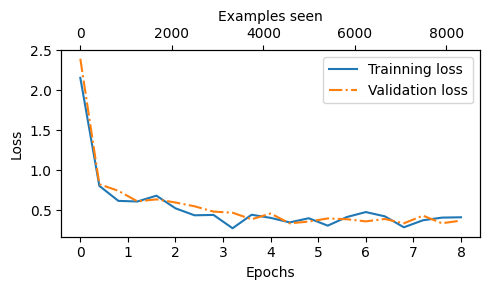

In [169]:
import matplotlib.pyplot as plt
def plot_values(epochs_seen, examples_seen, train_values, val_values, label='loss'): 
    fig, ax1 = plt.subplots(figsize=(5,3))
    ax1.plot(epochs_seen, train_values, label=f"Trainning {label}")
    ax1.plot(
        epochs_seen, val_values, linestyle="-.", 
        label = f"Validation {label}"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)   
    ax2.set_xlabel("Examples seen")
    fig.tight_layout()            
    plt.savefig(f"{label}-plot.pdf")
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)
    

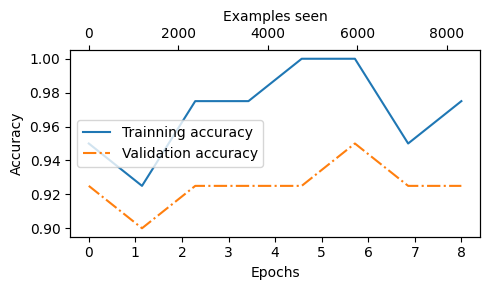

In [173]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs,
    label="accuracy"
)

In [174]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 98.08%
Validation accuracy: 97.32%
Test accuracy: 96.67%


### Using the LLM as a sapm classfier

In [177]:
def classify_review(text, model, tokenizer, device , max_length=None, pad_token_id = 50256): 
    model.eval()
    input_ids = tokenizer.encode(text)
    supported_context_length = model.transformer.wpe.weight.shape[0]
    input_ids = input_ids[:min(max_length, supported_context_length)]
    input_ids += [pad_token_id] * (max_length-len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)
    with torch.no_grad(): 
        logits = model(input_tensor).logits[:,-1,:]
    predicted_label = torch.argmax(logits, dim=-1).item()
    return "spam" if predicted_label ==1 else "not spam"

In [178]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)
print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [179]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)
print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [182]:
torch.save(model.state_dict(), "review_classifier.pth")


In [184]:
model_state_dict = torch.load(
    "review_classifier.pth",
    map_location=device,
    weights_only=True
)
model.load_state_dict(model_state_dict)

<All keys matched successfully>

In [185]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

model = GPT2LMHeadModel.from_pretrained(model_name)

# phải thay head giống lúc train
model.lm_head = torch.nn.Linear(768, 2)

# load trọng số đã train
model_state_dict = torch.load(
    "review_classifier.pth",
    map_location=device,
    weights_only=True
)
model.load_state_dict(model_state_dict)

model.to(device)
model.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=2, bias=True)
)

In [186]:
text = "You won $1000 cash prize!"
print(classify_review(text, model, tokenizer, device, max_length=120))

spam
